In [ ]:
## Creadi card fraud detection dataset
# https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [2]:
import pandas as pd

In [19]:
data_path = r"D:\Coding\DeepLearning\Datasets\creditcard.csv"

df = pd.read_csv(data_path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [20]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

<Axes: xlabel='Class'>

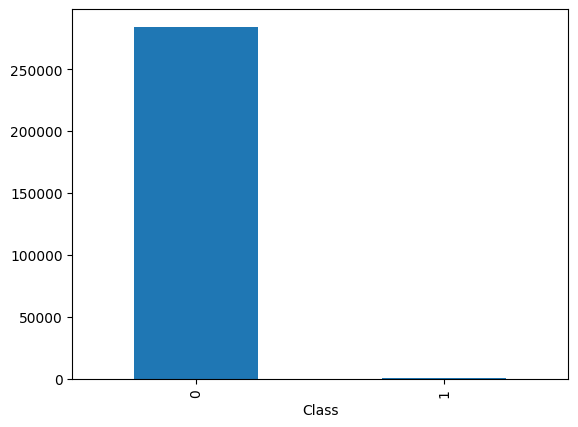

In [21]:
df.value_counts(df["Class"]).plot(kind="bar")

In [22]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [23]:
## Initially we will create an ANN and solve the problem
## will use some weignt handling technique to solve this imbalanced problem

In [24]:
X=df.iloc[:,1:30]
y=df.iloc[:,-1]

In [25]:
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [26]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [28]:
y_train.value_counts()

Class
0    199019
1       345
Name: count, dtype: int64

In [29]:
X_train.shape

(199364, 29)

In [30]:
## 
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [31]:
n_inputs=29

## define model
model = Sequential()
# first hidden layer
model.add(Dense(50, activation='relu', input_dim=n_inputs, kernel_initializer='he_normal'))
# define output layer
model.add(Dense(1, activation='sigmoid'))
# define loass and optimizer
model.compile(loss='binary_crossentropy', optimizer='adam')
model.fit(X_train, y_train, epochs=10)

Epoch 1/10

6231/6231 [==============================] - 17s 3ms/step - loss: 0.0321
Epoch 2/10
6231/6231 [==============================] - 16s 3ms/step - loss: 0.0167
Epoch 3/10
6231/6231 [==============================] - 16s 3ms/step - loss: 0.0102
Epoch 4/10
6231/6231 [==============================] - 16s 3ms/step - loss: 0.0090
Epoch 5/10
6231/6231 [==============================] - 16s 3ms/step - loss: 0.0099
Epoch 6/10
6231/6231 [==============================] - 16s 3ms/step - loss: 0.0091
Epoch 7/10
6231/6231 [==============================] - 16s 3ms/step - loss: 0.0071
Epoch 8/10
6231/6231 [==============================] - 16s 3ms/step - loss: 0.0097
Epoch 9/10
6231/6231 [==============================] - 16s 3ms/step - loss: 0.0076
Epoch 10/10
6231/6231 [==============================] - 16s 3ms/step - loss: 0.0086


In [32]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, model.predict(X_test))

2671/2671 [==============================] - 7s 2ms/step


0.9278758914933447

In [33]:
## weighted neural network with Keras

# define a weight and train the model with those weights

In [34]:
weight_assigned = {0:1, 1:550} ## 1:550 means 1 is 550 times more important than 0

In [35]:

## define model
model = Sequential()
# first hidden layer
model.add(Dense(50, activation='relu', input_dim=n_inputs, kernel_initializer='he_normal'))
# define output layer
model.add(Dense(1, activation='sigmoid'))
# define loass and optimizer
model.compile(loss='binary_crossentropy', optimizer='adam')
model.fit(X_train, y_train, class_weight=weight_assigned, epochs=10)

Epoch 1/10
6231/6231 [==============================] - 21s 3ms/step - loss: 3.6535
Epoch 2/10
6231/6231 [==============================] - 21s 3ms/step - loss: 3.0788
Epoch 3/10
6231/6231 [==============================] - 22s 4ms/step - loss: 2.4753
Epoch 4/10
6231/6231 [==============================] - 21s 3ms/step - loss: 2.8343
Epoch 5/10
6231/6231 [==============================] - 20s 3ms/step - loss: 3.1280
Epoch 6/10
6231/6231 [==============================] - 21s 3ms/step - loss: 1.9572
Epoch 7/10
6231/6231 [==============================] - 20s 3ms/step - loss: 2.5623
Epoch 8/10
6231/6231 [==============================] - 20s 3ms/step - loss: 2.6561
Epoch 9/10
6231/6231 [==============================] - 20s 3ms/step - loss: 2.2605
Epoch 10/10
6231/6231 [==============================] - 18s 3ms/step - loss: 1.8363


In [36]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, model.predict(X_test))

2671/2671 [==============================] - 6s 2ms/step


0.9451644262094258